In [1]:
from scipy import stats
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pyproj import Transformer
from matplotlib.ticker import FormatStrFormatter
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

In [39]:
df = pd.read_csv("C:/Users/LHansen/OneDrive - Land Information New Zealand/2025/Python/Scripts/Elliot_Sinclair_converted_coordinates.csv")

print(df.head())

   Unnamed: 0             x            y             z        date station  \
0  2025-01-02 -4.593460e+06  588296.3431 -4.371063e+06  2025-01-02    ESBR   
1  2025-01-02 -4.592307e+06  595895.7358 -4.371256e+06  2025-01-02    ESTR   
2  2025-01-02 -4.584753e+06  613237.8326 -4.376791e+06  2025-01-02    ESRN   
3  2025-01-02 -4.763458e+06  566822.9088 -4.189381e+06  2025-01-02    ESNL   
4  2025-01-02 -4.441554e+06  843480.1000 -4.484324e+06  2025-01-02    ESPM   

   nztm2000_lon  nztm2000_lat  nzvd2016_elev  
0  5.179362e+06  1.575901e+06        11.0693  
1  5.179072e+06  1.568221e+06        19.6716  
2  5.171353e+06  1.550094e+06        50.7125  
3  5.425453e+06  1.617914e+06        14.0216  
4  5.014696e+06  1.304014e+06       220.2505  


In [35]:
df['date'] = pd.to_datetime(df['date'], dayfirst=True, errors='coerce')



In [36]:


# Ensure 'date' is a datetime type
df['date'] = pd.to_datetime(df['date'])

# Set 'date' as the index
df.set_index('date', inplace=True)

# Function to calculate RMS
def calculate_rms(series):
    return np.sqrt(np.mean(series**2))

# Resample data to fortnightly and monthly time series
fortnightly_data = df.groupby(['station', pd.Grouper(freq='2W')])[
    ['nztm2000_lon', 'nztm2000_lat', 'nzvd2016_elev']
].mean().reset_index()

monthly_data = df.groupby(['station', pd.Grouper(freq='ME')])[
    ['nztm2000_lon', 'nztm2000_lat', 'nzvd2016_elev']
].mean().reset_index()

# Calculate RMS for each component of coordinate for each station on a fortnightly time series
fortnightly_rms = fortnightly_data.groupby('station').agg({
    'nztm2000_lon': calculate_rms,
    'nztm2000_lat': calculate_rms,
    'nzvd2016_elev': calculate_rms
}).rename(columns={
    'nztm2000_lon': 'nztm2000_lon_rms',
    'nztm2000_lat': 'nztm2000_lat_rms',
    'nzvd2016_elev': 'nzvd2016_elev_rms'
})

# Calculate RMS for each component of coordinate for each station on a monthly time series
monthly_rms = monthly_data.groupby('station').agg({
    'nztm2000_lon': calculate_rms,
    'nztm2000_lat': calculate_rms,
    'nzvd2016_elev': calculate_rms
}).rename(columns={
    'nztm2000_lon': 'nztm2000_lon_rms',
    'nztm2000_lat': 'nztm2000_lat_rms',
    'nzvd2016_elev': 'nzvd2016_elev_rms'
})

# Print the results
print("Fortnightly RMS values:")
print(fortnightly_rms)
print("\nMonthly RMS values:")
print(monthly_rms)


Fortnightly RMS values:
         nztm2000_lon_rms  nztm2000_lat_rms  nzvd2016_elev_rms
station                                                       
ESBR         5.179362e+06      1.575901e+06          11.060269
ESGM         5.296227e+06      1.450951e+06          14.278896
ESKV         5.228535e+06      1.585853e+06         299.435667
ESNL         5.425453e+06      1.617914e+06          14.025537
ESPM         5.014696e+06      1.304014e+06         220.258031
ESQT         5.006862e+06      1.265587e+06         363.406935
ESRN         5.171353e+06      1.550094e+06          50.707660
ESTR         5.179072e+06      1.568221e+06          19.670790

Monthly RMS values:
         nztm2000_lon_rms  nztm2000_lat_rms  nzvd2016_elev_rms
station                                                       
ESBR         5.179362e+06      1.575901e+06          11.059873
ESGM         5.296227e+06      1.450951e+06          14.278546
ESKV         5.228535e+06      1.585853e+06         299.435376
ESNL      

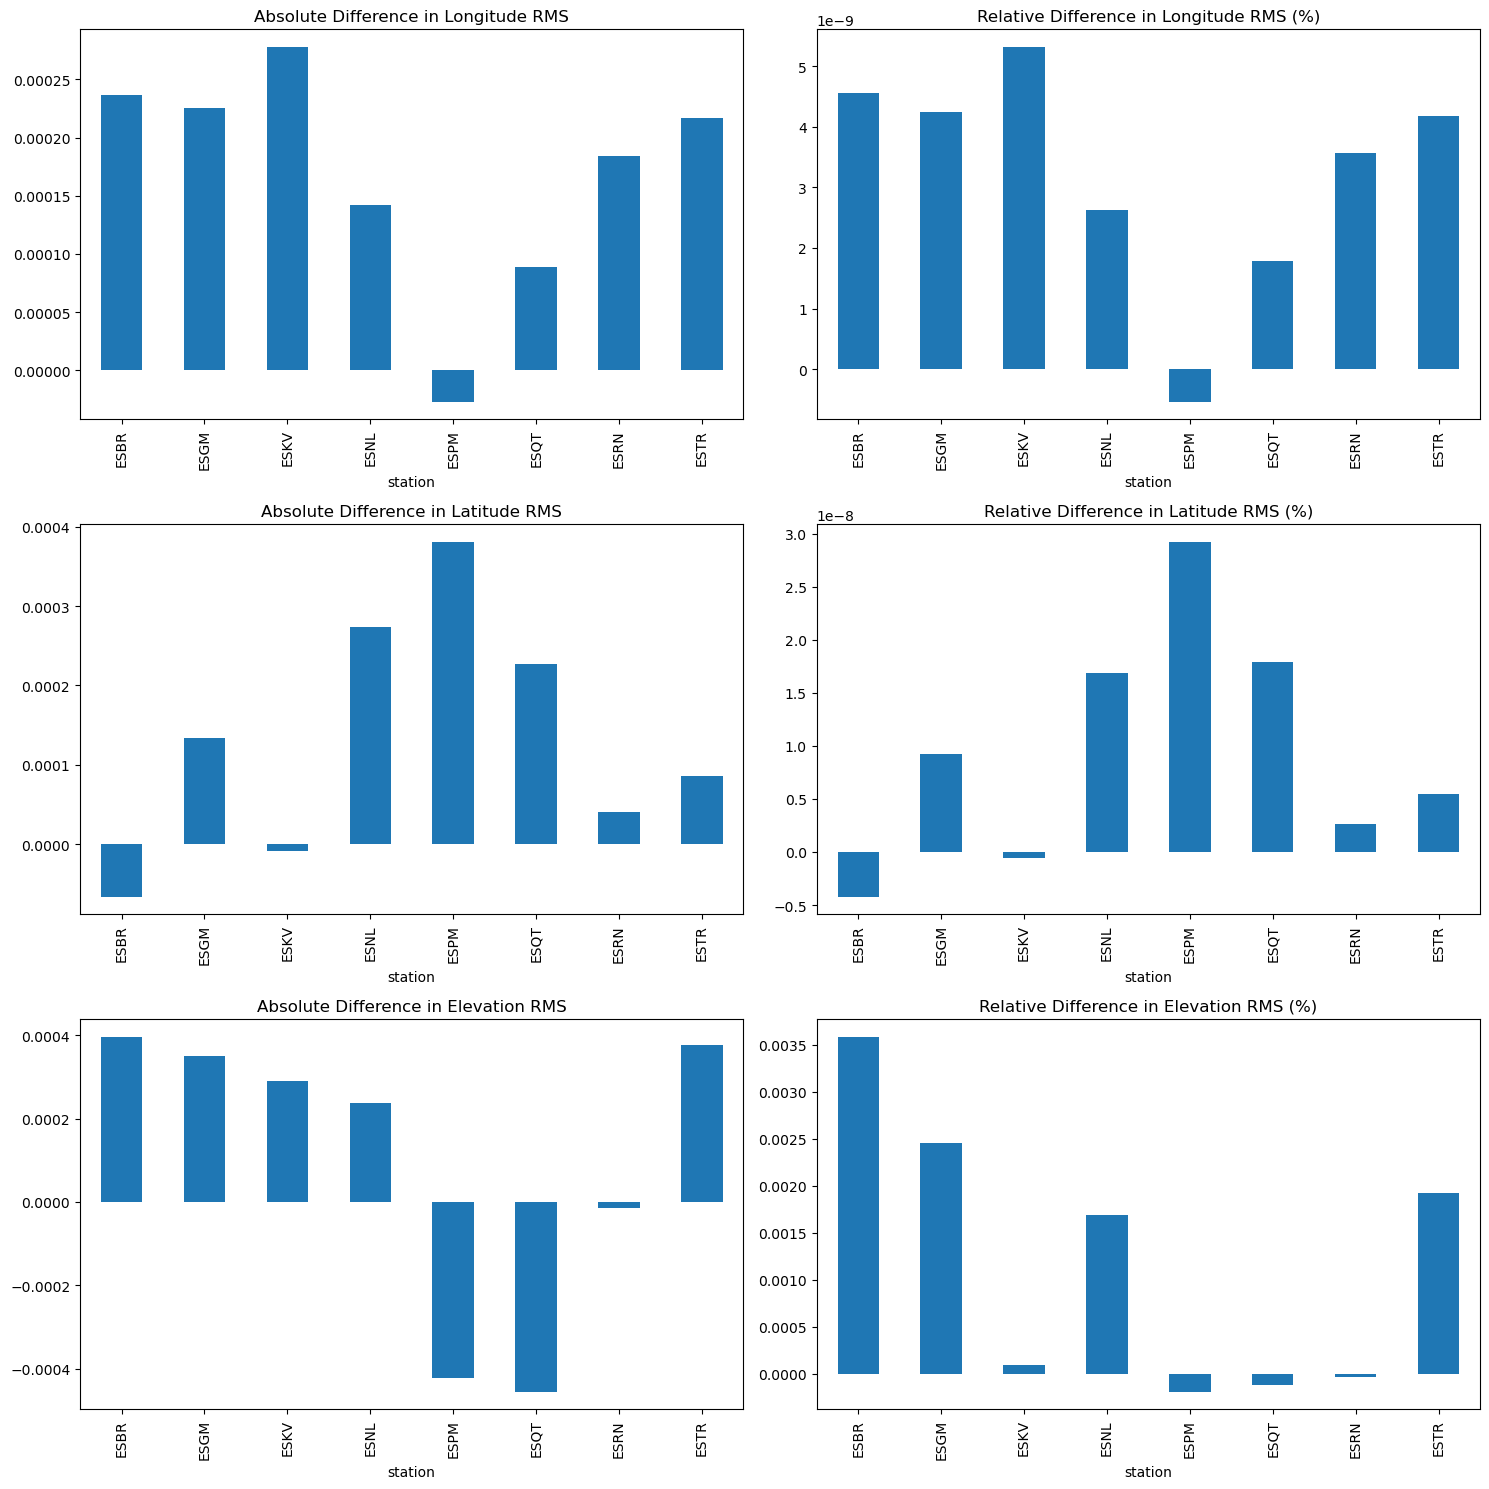

In [37]:
# Assuming you already have these from your earlier code
# fortnightly_rms and monthly_rms are DataFrames with station as index

# Calculate absolute and relative differences
absolute_diff = fortnightly_rms - monthly_rms
relative_diff = (absolute_diff / monthly_rms) * 100

# Plotting
fig, axes = plt.subplots(3, 2, figsize=(15, 15))

# Absolute differences
absolute_diff['nztm2000_lon_rms'].plot(kind='bar', ax=axes[0, 0], title='Absolute Difference in Longitude RMS')
absolute_diff['nztm2000_lat_rms'].plot(kind='bar', ax=axes[1, 0], title='Absolute Difference in Latitude RMS')
absolute_diff['nzvd2016_elev_rms'].plot(kind='bar', ax=axes[2, 0], title='Absolute Difference in Elevation RMS')

# Relative differences
relative_diff['nztm2000_lon_rms'].plot(kind='bar', ax=axes[0, 1], title='Relative Difference in Longitude RMS (%)')
relative_diff['nztm2000_lat_rms'].plot(kind='bar', ax=axes[1, 1], title='Relative Difference in Latitude RMS (%)')
relative_diff['nzvd2016_elev_rms'].plot(kind='bar', ax=axes[2, 1], title='Relative Difference in Elevation RMS (%)')



# Layout adjustments
plt.tight_layout()
fig.savefig("Elliot_sinclair_rms_comparison.jpg", dpi=300, bbox_inches='tight')
plt.show()

In [6]:
# Group by 'stations' and calculate median and standard deviation for the specified columns
grouped = df.groupby('station').agg({
    'nztm2000_lon': ['median', 'std'],
    'nztm2000_lat': ['median', 'std'],
    'nzvd2016_elev': ['median', 'std']
})

# Calculate median +/- standard deviation
grouped['nztm2000_lon', 'median +/- std'] = grouped['nztm2000_lon', 'median'] + grouped['nztm2000_lon', 'std']
grouped['nztm2000_lat', 'median +/- std'] = grouped['nztm2000_lat', 'median'] + grouped['nztm2000_lat', 'std']
grouped['nzvd2016_elev', 'median +/- std'] = grouped['nzvd2016_elev', 'median'] + grouped['nzvd2016_elev', 'std']

# Print the result
print(grouped)


        nztm2000_lon            nztm2000_lat           nzvd2016_elev  \
              median       std        median       std        median   
station                                                                
ESBR     5179361.594  0.002946  1.575901e+06  0.003088      11.05985   
ESGM     5296227.191  0.002865  1.450951e+06  0.001857      14.27925   
ESKV     5228534.889  0.002865  1.585853e+06  0.003269     299.43555   
ESNL     5425453.297  0.003058  1.617914e+06  0.002421      14.02465   
ESPM     5014695.787  0.003318  1.304014e+06  0.003255     220.25850   
ESQT     5006861.759  0.002292  1.265587e+06  0.003551     363.40830   
ESRN     5171353.061  0.002871  1.550094e+06  0.002651      50.70805   
ESTR     5179071.578  0.002859  1.568221e+06  0.002869      19.67055   

                    nztm2000_lon   nztm2000_lat  nzvd2016_elev  
              std median +/- std median +/- std median +/- std  
station                                                         
ESBR     0.0

In [40]:
print(df.columns)

Index(['Unnamed: 0', 'x', 'y', 'z', 'date', 'station', 'nztm2000_lon',
       'nztm2000_lat', 'nzvd2016_elev'],
      dtype='object')


In [41]:
print(df['date'].isnull().sum())

0


In [42]:
print(df['date'].dtype)

object


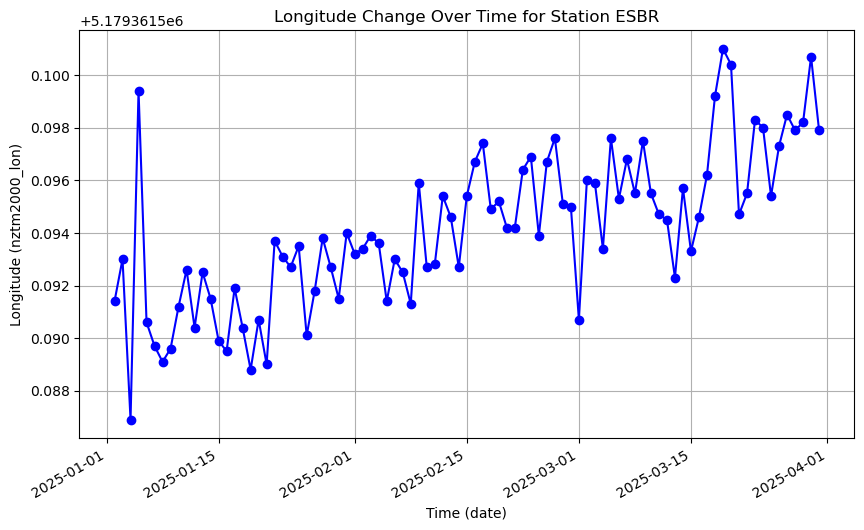

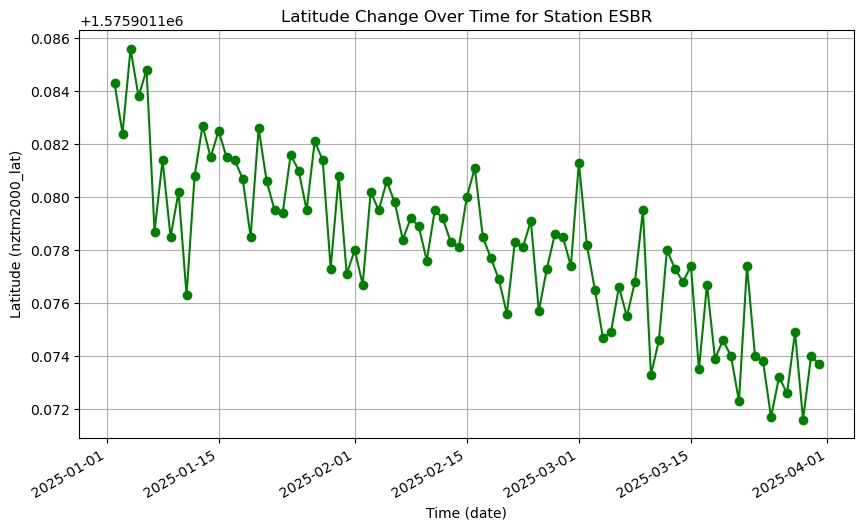

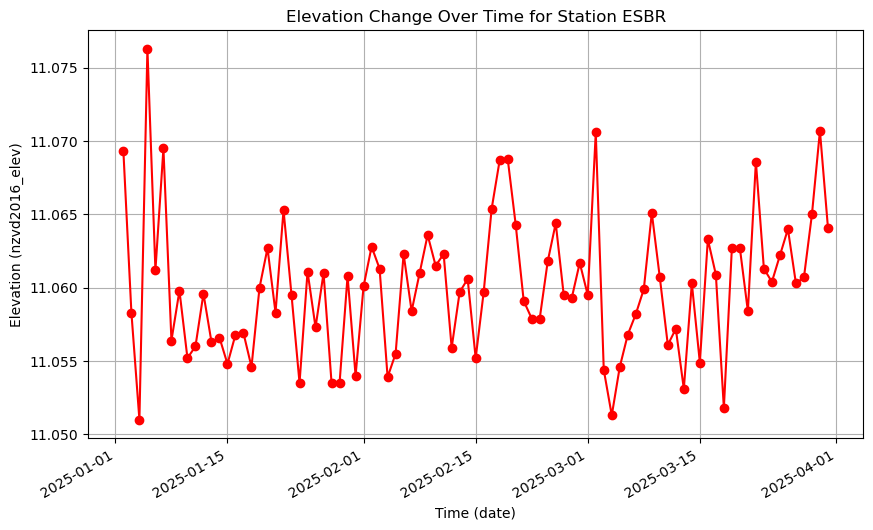

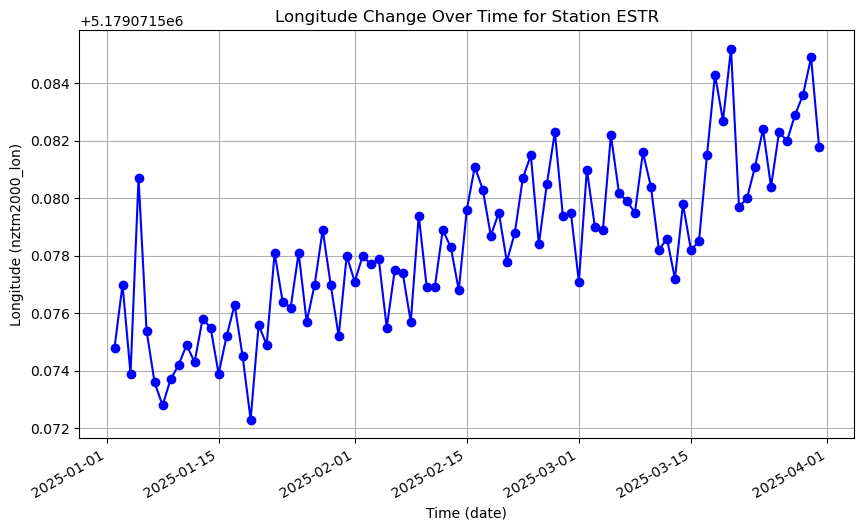

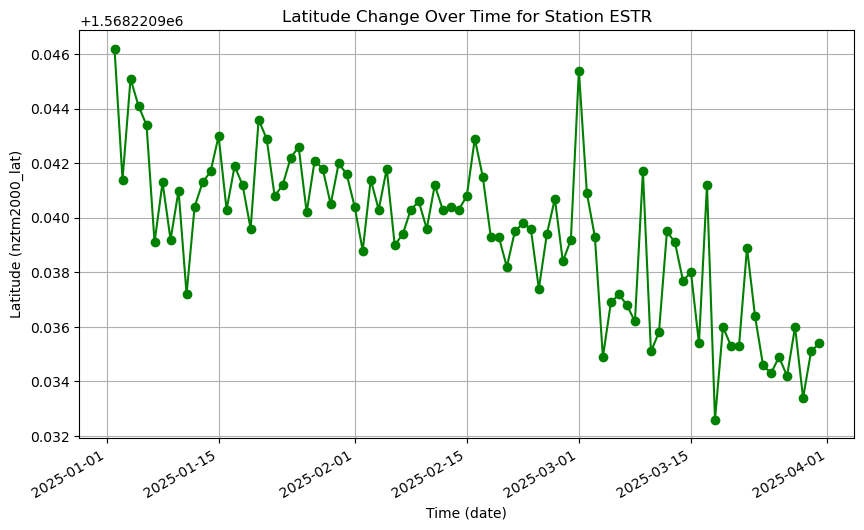

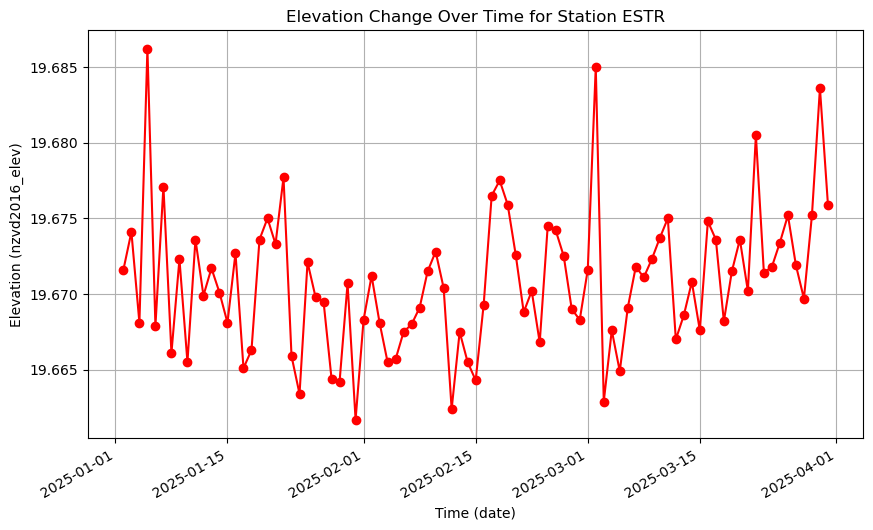

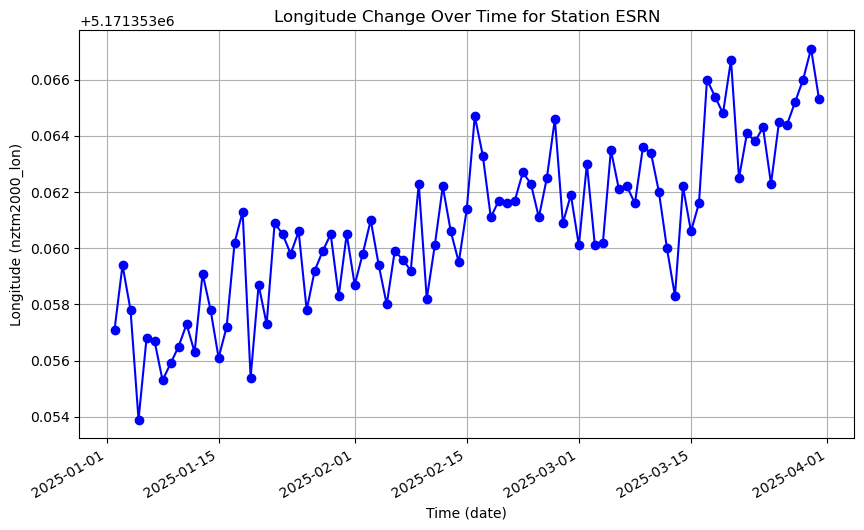

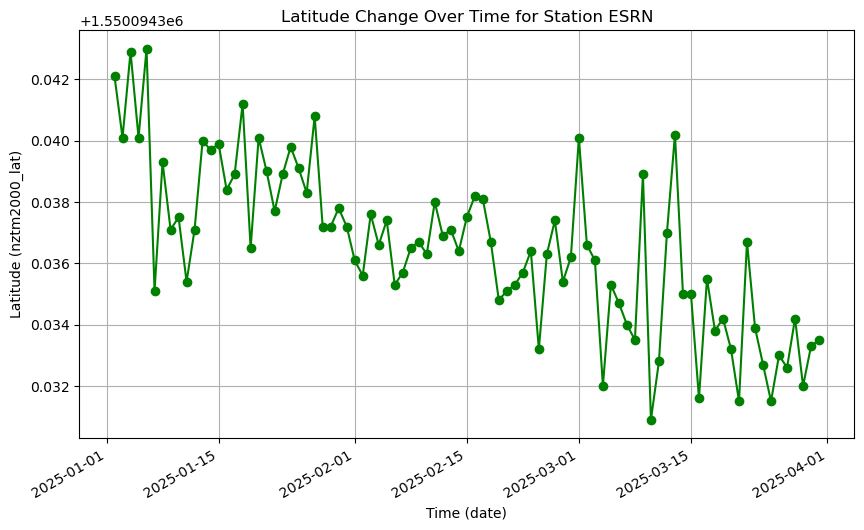

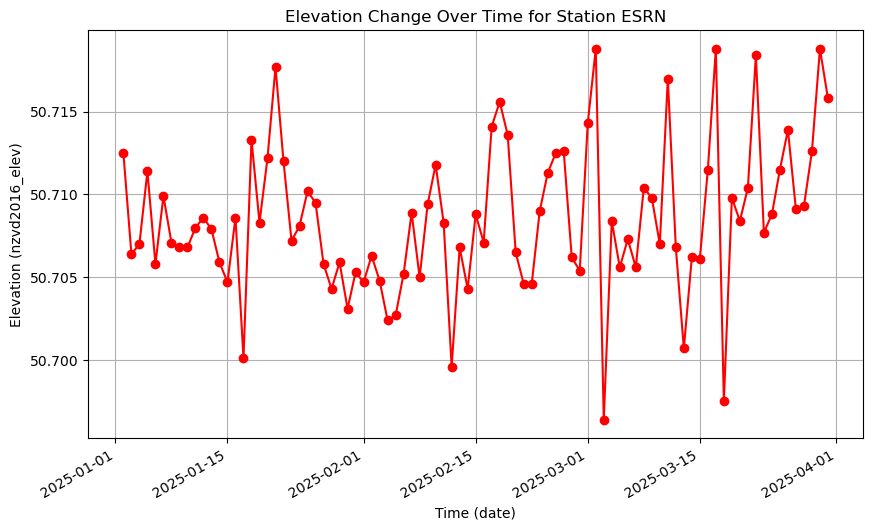

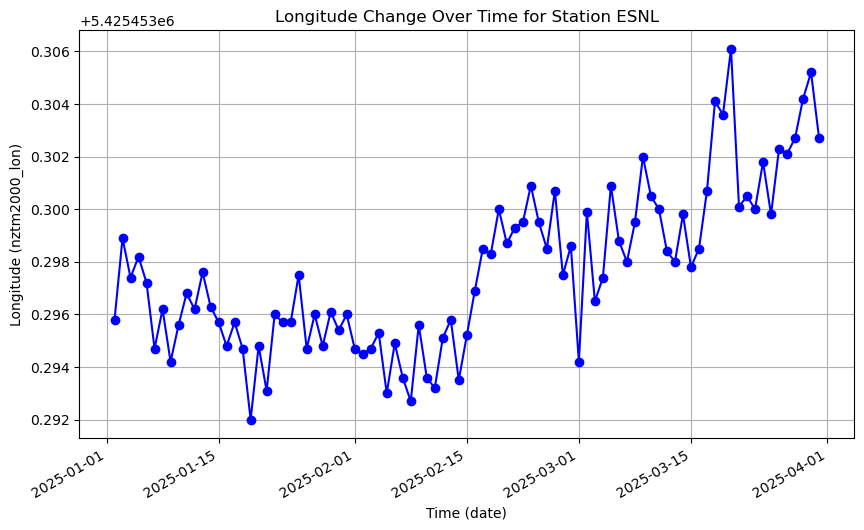

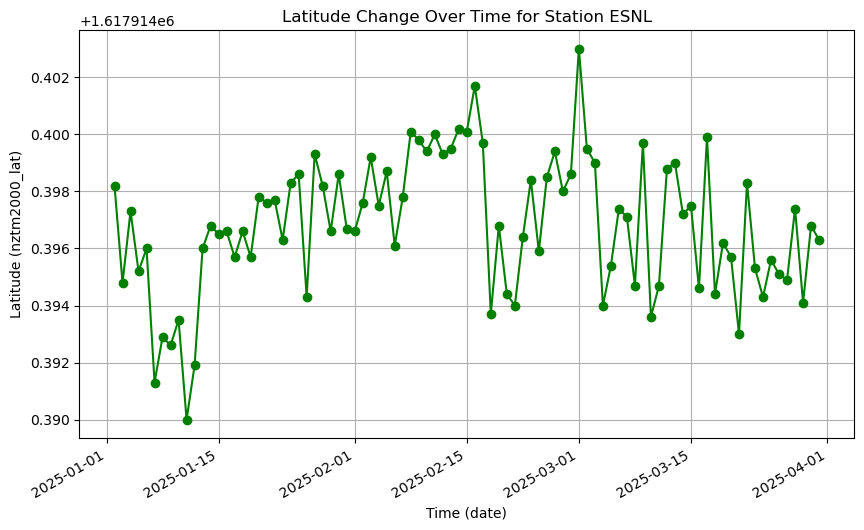

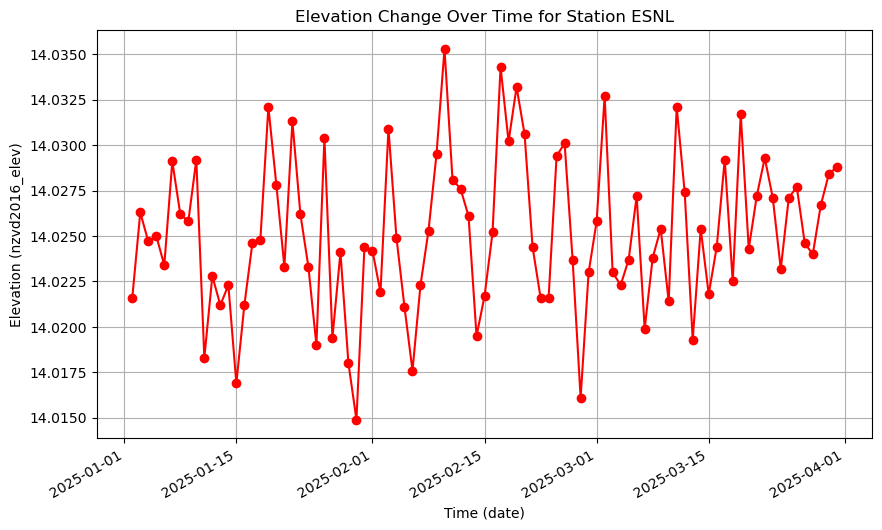

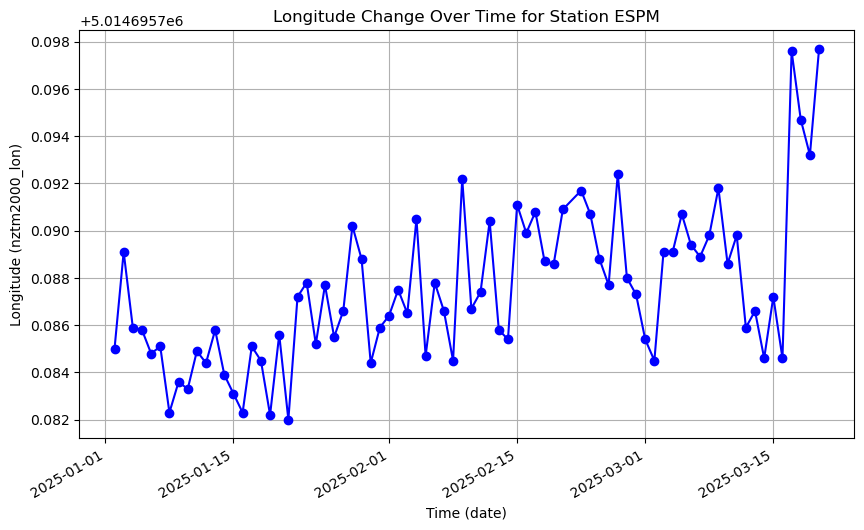

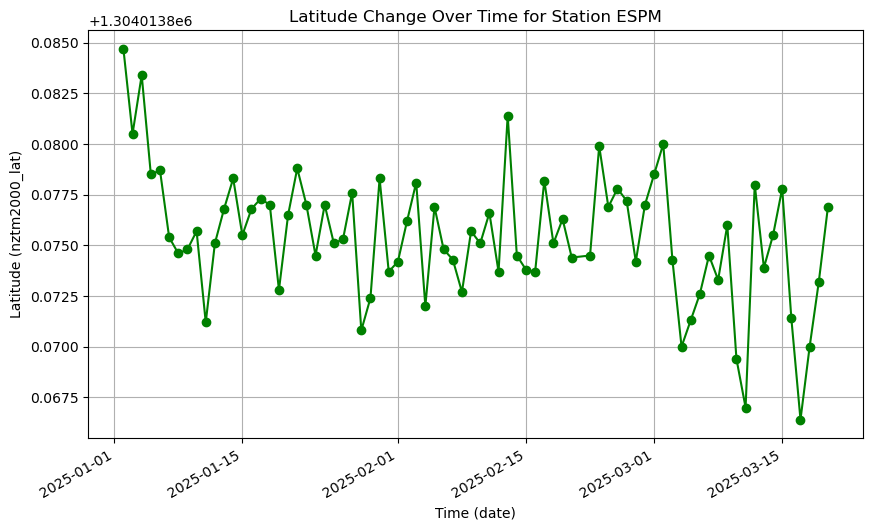

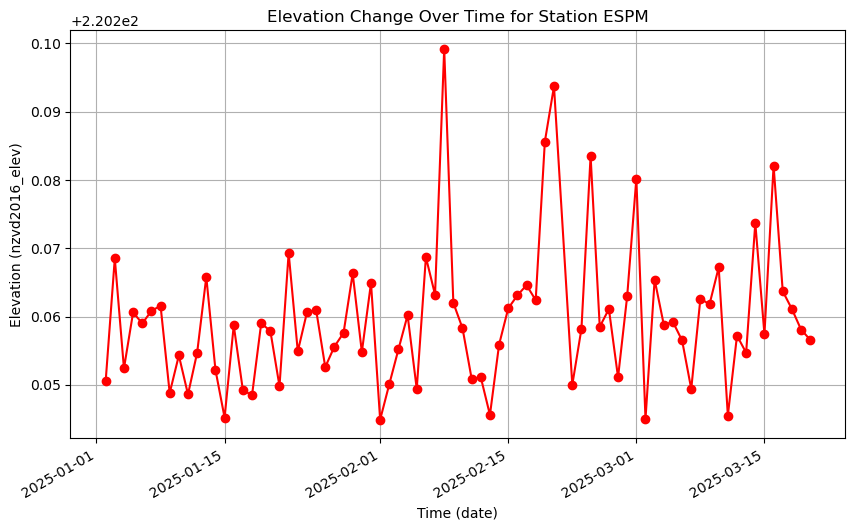

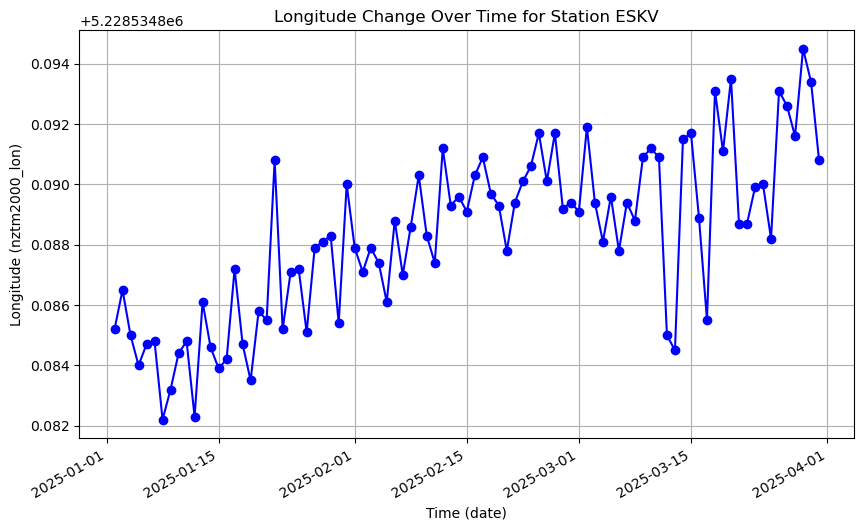

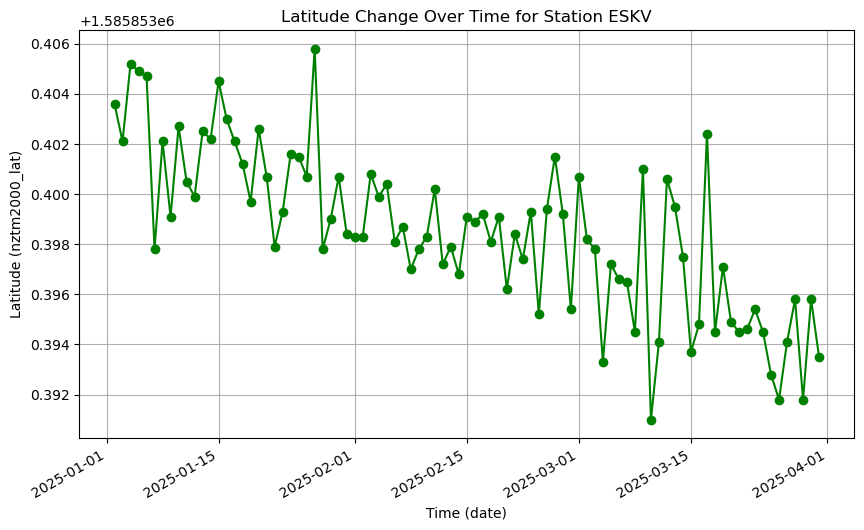

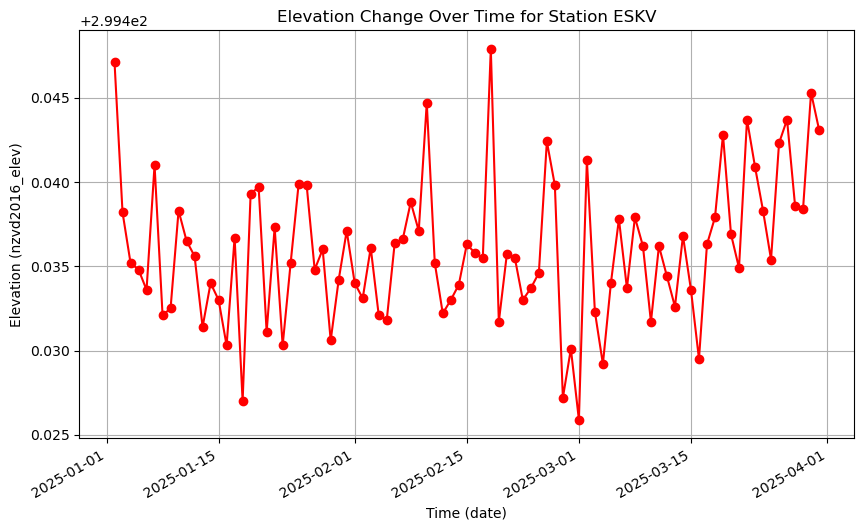

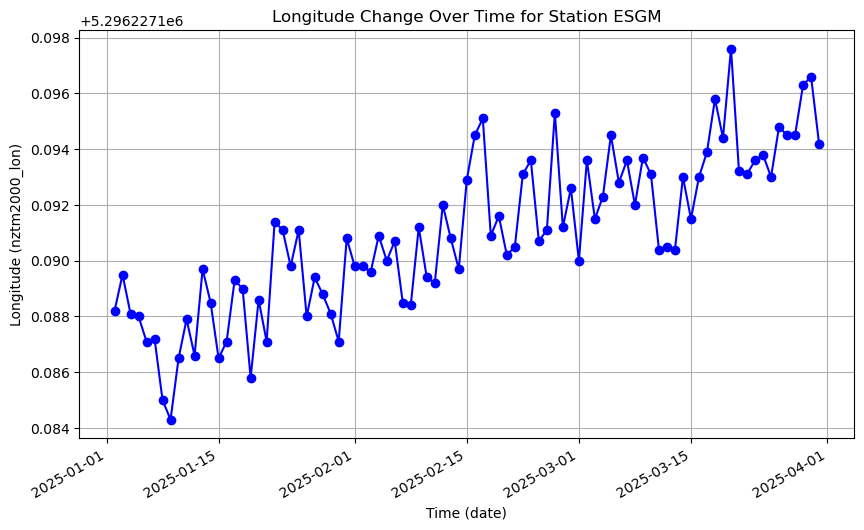

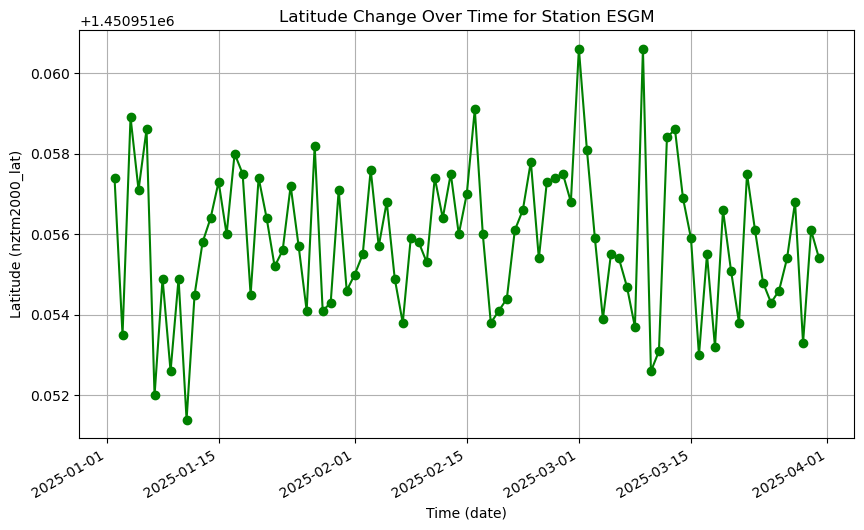

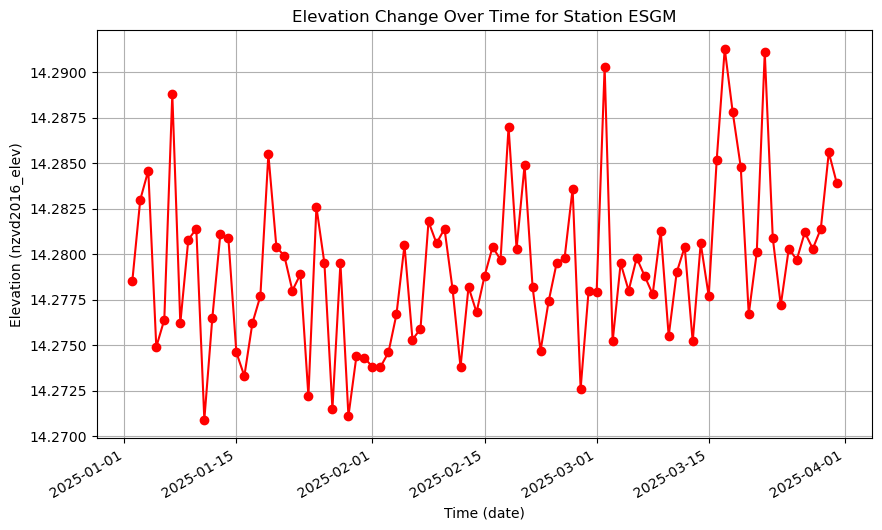

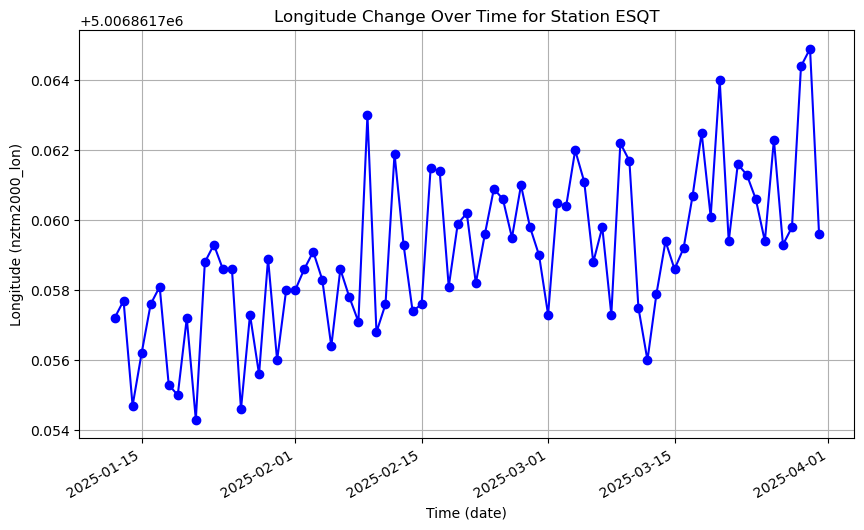

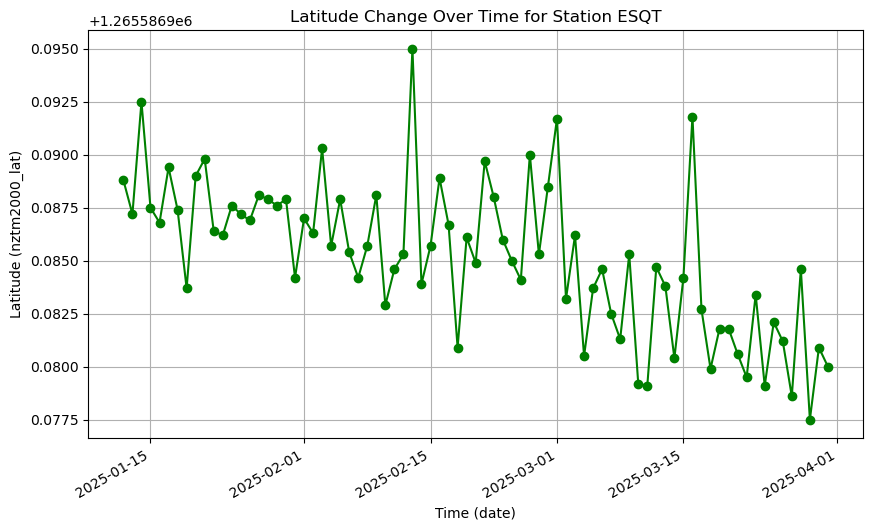

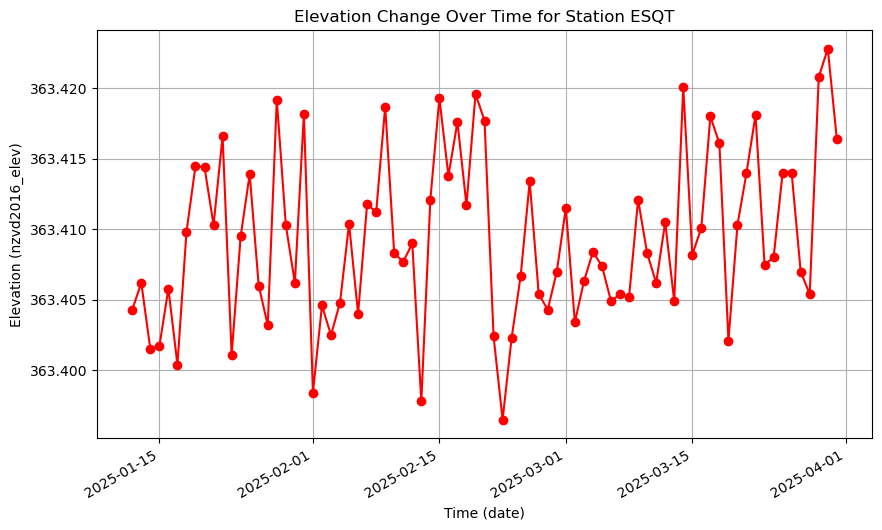

In [43]:

# Convert 'date' to datetime
df['date'] = pd.to_datetime(df['date'])

# Get unique stations
stations = df['station'].unique()

# Iterate over each station and create individual plots
for station in stations:
    station_data = df[df['station'] == station]
    
    # Plot longitude change over time
    plt.figure(figsize=(10, 6))
    plt.plot(station_data['date'], station_data['nztm2000_lon'], marker='o', linestyle='-', color='b')
    plt.title(f'Longitude Change Over Time for Station {station}')
    plt.xlabel('Time (date)')
    plt.ylabel('Longitude (nztm2000_lon)')
    plt.grid(True)
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.gcf().autofmt_xdate()
    plt.show()
    
    # Plot latitude change over time
    plt.figure(figsize=(10, 6))
    plt.plot(station_data['date'], station_data['nztm2000_lat'], marker='o', linestyle='-', color='g')
    plt.title(f'Latitude Change Over Time for Station {station}')
    plt.xlabel('Time (date)')
    plt.ylabel('Latitude (nztm2000_lat)')
    plt.grid(True)
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.gcf().autofmt_xdate()
    plt.show()
    
    # Plot elevation change over time
    plt.figure(figsize=(10, 6))
    plt.plot(station_data['date'], station_data['nzvd2016_elev'], marker='o', linestyle='-', color='r')
    plt.title(f'Elevation Change Over Time for Station {station}')
    plt.xlabel('Time (date)')
    plt.ylabel('Elevation (nzvd2016_elev)')
    plt.grid(True)
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.gcf().autofmt_xdate()
    plt.show()
